# Combine Lowest-Parameter TT Configurations

This notebook combines multiple `lowest_parameter_shapes_by_core_count.csv` files into one shared configuration table.

It is useful when different weight families have different TT-shape searches, such as:
- `q_proj` and `o_proj` sharing one CSV
- `k_proj` and `v_proj` sharing another CSV

The notebook:
- accepts reusable folder and CSV paths
- aligns sources by `total_cores`
- computes combined parameter counts
- preserves the source TT shapes and factorization details
- saves one combined CSV for later filtering or manifest generation


In [3]:
from pathlib import Path
import ast
import json

try:
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        "This notebook needs pandas. Please use the characterize-ttlora environment."
    ) from exc

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

phase_root = Path('/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study')
analysis_root = phase_root / 'analysis'
output_dir = phase_root / 'analysis_outputs' / 'combined_parameter_configs'
output_dir.mkdir(parents=True, exist_ok=True)

# Edit this list for any future mixed-family combination.
# `multiplier` is how many attention weights share that CSV family.
SOURCE_SPECS = [
    {
        'label': 'kv',
        'folder_path': analysis_root / 'parameter_space_notebook_llama3.2-1b_kv',
        'csv_path': analysis_root / 'parameter_space_notebook_llama3.2-1b_kv' / 'lowest_parameter_shapes_by_core_count.csv',
        'multiplier': 2,
        'description': 'Shared by k_proj and v_proj',
    },
    {
        'label': 'qo',
        'folder_path': analysis_root / 'parameter_space_notebook_llama3.2-1b_qo',
        'csv_path': analysis_root / 'parameter_space_notebook_llama3.2-1b_qo' / 'lowest_parameter_shapes_by_core_count.csv',
        'multiplier': 2,
        'description': 'Shared by q_proj and o_proj',
    },
]

# Use 'inner' for only shared valid core counts, or 'outer' to keep every core count.
join_mode = 'inner'

output_csv_name = 'llama3_2_1b_kv_qo_combined_lowest_parameter_configs.csv'
output_csv_path = output_dir / output_csv_name

SOURCE_SPECS


[{'label': 'kv',
  'folder_path': PosixPath('/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_kv'),
  'csv_path': PosixPath('/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_kv/lowest_parameter_shapes_by_core_count.csv'),
  'multiplier': 2,
  'description': 'Shared by k_proj and v_proj'},
 {'label': 'qo',
  'folder_path': PosixPath('/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo'),
  'csv_path': PosixPath('/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo/lowest_parameter_shapes_by_core_count.csv'),
  'multiplier': 2,
  'description': 'Shared by q_proj and o_proj'}]

In [4]:
def parse_literal(value):
    if pd.isna(value):
        return value
    if not isinstance(value, str):
        return value
    text = value.strip()
    if not text:
        return value
    if text[0] not in '[({"\'':
        return value
    try:
        return ast.literal_eval(text)
    except (ValueError, SyntaxError):
        return value


def load_source(spec):
    csv_path = Path(spec['csv_path'])
    folder_path = Path(spec.get('folder_path', csv_path.parent))
    metadata_path = folder_path / 'parameter_space_metadata.json'

    if not csv_path.exists():
        raise FileNotFoundError(f'CSV not found: {csv_path}')

    df = pd.read_csv(csv_path)
    if 'total_cores' not in df.columns:
        raise ValueError(f"Missing 'total_cores' in {csv_path}")
    if 'per_matrix_params' not in df.columns:
        raise ValueError(f"Missing 'per_matrix_params' in {csv_path}")

    if df['total_cores'].duplicated().any():
        duplicate_cores = sorted(df.loc[df['total_cores'].duplicated(), 'total_cores'].unique())
        raise ValueError(f'{csv_path} has duplicate total_cores entries: {duplicate_cores}')

    for col in (
        'weight_shape',
        'input_factors',
        'output_factors',
        'tt_shape',
    ):
        if col in df.columns:
            df[col] = df[col].apply(parse_literal)

    numeric_cols = [
        'total_cores',
        'per_matrix_params',
        'per_layer_qkv_params',
        'all_layers_qkv_params',
        'num_layers',
        'adapted_weights_per_layer',
        'input_cores',
        'output_cores',
        'num_shapes',
        'num_unique_total_param_counts',
        'in_features',
        'out_features',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    metadata = {}
    if metadata_path.exists():
        with open(metadata_path) as f:
            metadata = json.load(f)

    multiplier = int(spec.get('multiplier', 1))
    label = spec['label']

    df = df.sort_values('total_cores').reset_index(drop=True)
    df[f'{label}_multiplier'] = multiplier
    df[f'{label}_source_csv'] = str(csv_path)
    df[f'{label}_source_folder'] = str(folder_path)
    df[f'{label}_description'] = spec.get('description', '')

    num_layers = int(df['num_layers'].dropna().iloc[0]) if 'num_layers' in df.columns else None
    df[f'{label}_combined_per_layer_params'] = df['per_matrix_params'] * multiplier
    if num_layers is not None:
        df[f'{label}_combined_all_layers_params'] = df[f'{label}_combined_per_layer_params'] * num_layers
    else:
        df[f'{label}_combined_all_layers_params'] = pd.NA

    summary = {
        'label': label,
        'csv_path': str(csv_path),
        'folder_path': str(folder_path),
        'description': spec.get('description', ''),
        'multiplier': multiplier,
        'weight_shape': metadata.get('weight_shape') or df.get('weight_shape', pd.Series([None])).iloc[0],
        'num_layers': num_layers,
        'min_total_cores': int(df['total_cores'].min()),
        'max_total_cores': int(df['total_cores'].max()),
        'num_rows': len(df),
    }

    keep_cols = [
        'total_cores',
        'weight_shape',
        'in_features',
        'out_features',
        'adapted_weights_per_layer',
        'num_layers',
        'num_shapes',
        'num_unique_total_param_counts',
        'all_layers_qkv_params',
        'per_layer_qkv_params',
        'per_matrix_params',
        'input_cores',
        'output_cores',
        'input_factors',
        'output_factors',
        'tt_shape',
        f'{label}_multiplier',
        f'{label}_combined_per_layer_params',
        f'{label}_combined_all_layers_params',
        f'{label}_source_csv',
        f'{label}_source_folder',
        f'{label}_description',
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    rename_map = {
        col: f'{label}_{col}'
        for col in keep_cols
        if col != 'total_cores' and not col.startswith(f'{label}_')
    }
    df = df[keep_cols].rename(columns=rename_map)
    return df, summary


In [5]:
loaded_frames = []
source_summaries = []

for spec in SOURCE_SPECS:
    frame, summary = load_source(spec)
    loaded_frames.append(frame)
    source_summaries.append(summary)

summary_df = pd.DataFrame(source_summaries)
display(summary_df)


,label,csv_path,folder_path,description,multiplier,weight_shape,num_layers,min_total_cores,max_total_cores,num_rows
0,kv,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by k_proj and v_proj,2,"[512, 2048]",16,2,20,19
1,qo,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj,2,"[2048, 2048]",16,2,22,21


In [6]:
if not loaded_frames:
    raise ValueError('SOURCE_SPECS is empty.')

num_layers_values = {summary['num_layers'] for summary in source_summaries if summary['num_layers'] is not None}
if len(num_layers_values) > 1:
    raise ValueError(f'All sources must share the same num_layers, found: {sorted(num_layers_values)}')
shared_num_layers = next(iter(num_layers_values)) if num_layers_values else None

combine_df = loaded_frames[0].copy()
merge_how = 'inner' if join_mode == 'inner' else 'outer'
for frame in loaded_frames[1:]:
    combine_df = combine_df.merge(frame, on='total_cores', how=merge_how)

combine_df = combine_df.sort_values('total_cores').reset_index(drop=True)

per_layer_component_cols = [
    col for col in combine_df.columns if col.endswith('_combined_per_layer_params')
]
all_layers_component_cols = [
    col for col in combine_df.columns if col.endswith('_combined_all_layers_params')
]
multiplier_cols = [
    col for col in combine_df.columns if col.endswith('_multiplier')
]

combine_df['combined_num_sources'] = len(source_summaries)
combine_df['combined_num_layers'] = shared_num_layers
combine_df['combined_adapted_weights_per_layer'] = combine_df[multiplier_cols].sum(axis=1)
combine_df['combined_per_layer_params'] = combine_df[per_layer_component_cols].sum(axis=1)
combine_df['combined_all_layers_params'] = combine_df[all_layers_component_cols].sum(axis=1)

ordered_front_cols = [
    'total_cores',
    'combined_num_sources',
    'combined_num_layers',
    'combined_adapted_weights_per_layer',
    'combined_per_layer_params',
    'combined_all_layers_params',
]
other_cols = [col for col in combine_df.columns if col not in ordered_front_cols]
combine_df = combine_df[ordered_front_cols + other_cols]

combine_df.to_csv(output_csv_path, index=False)

print(f'join_mode: {join_mode}')
print(f'rows in combined table: {len(combine_df)}')
print(f'saved combined csv: {output_csv_path}')
display(combine_df.head(10))


join_mode: inner
rows in combined table: 19
saved combined csv: /home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis_outputs/combined_parameter_configs/llama3_2_1b_kv_qo_combined_lowest_parameter_configs.csv


,total_cores,combined_num_sources,combined_num_layers,combined_adapted_weights_per_layer,combined_per_layer_params,combined_all_layers_params,kv_weight_shape,kv_in_features,kv_out_features,kv_adapted_weights_per_layer,...,qo_output_cores,qo_input_factors,qo_output_factors,qo_tt_shape,qo_multiplier,qo_combined_per_layer_params,qo_combined_all_layers_params,qo_source_csv,qo_source_folder,qo_description
0,2,2,16,4,79872,1277952,"[512, 2048]",2048,512,2,...,1,[2048],[2048],"[2048, 2048]",2,49152,786432,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
1,3,2,16,4,36096,577536,"[512, 2048]",2048,512,2,...,2,[2048],"[128, 16]","[2048, 16, 128]",2,27264,436224,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
2,4,2,16,4,9408,150528,"[512, 2048]",2048,512,2,...,2,"[128, 16]","[128, 16]","[128, 16, 16, 128]",2,5376,86016,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
3,5,2,16,4,7104,113664,"[512, 2048]",2048,512,2,...,3,"[128, 16]","[32, 8, 8]","[128, 16, 8, 8, 32]",2,4224,67584,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
4,6,2,16,4,5568,89088,"[512, 2048]",2048,512,2,...,3,"[32, 8, 8]","[32, 8, 8]","[32, 8, 8, 8, 8, 32]",2,3072,49152,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
5,7,2,16,4,4992,79872,"[512, 2048]",2048,512,2,...,4,"[32, 8, 8]","[32, 4, 4, 4]","[32, 8, 8, 4, 4, 4, 32]",2,2784,44544,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
6,8,2,16,4,4656,74496,"[512, 2048]",2048,512,2,...,4,"[32, 4, 4, 4]","[32, 4, 4, 4]","[32, 4, 4, 4, 4, 4, 4, 32]",2,2496,39936,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
7,9,2,16,4,4560,72960,"[512, 2048]",2048,512,2,...,5,"[32, 4, 4, 4]","[16, 2, 4, 4, 4]","[32, 4, 4, 4, 4, 4, 4, 2, 16]",2,2448,39168,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
8,10,2,16,4,4512,72192,"[512, 2048]",2048,512,2,...,5,"[16, 2, 4, 4, 4]","[16, 2, 4, 4, 4]","[16, 2, 4, 4, 4, 4, 4, 4, 2, 16]",2,2400,38400,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj
9,11,2,16,4,4512,72192,"[512, 2048]",2048,512,2,...,6,"[16, 2, 4, 4, 4]","[16, 2, 2, 2, 4, 4]","[16, 2, 4, 4, 4, 4, 4, 2, 2, 2, 16]",2,2400,38400,/home/pkunwar/characterize_ttlora/phases/2.1.t...,/home/pkunwar/characterize_ttlora/phases/2.1.t...,Shared by q_proj and o_proj


In [7]:
result_summary = {
    'output_csv_path': str(output_csv_path),
    'join_mode': join_mode,
    'num_rows': int(len(combine_df)),
    'min_total_cores': int(combine_df['total_cores'].min()) if len(combine_df) else None,
    'max_total_cores': int(combine_df['total_cores'].max()) if len(combine_df) else None,
    'combined_num_layers': int(shared_num_layers) if shared_num_layers is not None else None,
    'sources': source_summaries,
}
result_summary


{'output_csv_path': '/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis_outputs/combined_parameter_configs/llama3_2_1b_kv_qo_combined_lowest_parameter_configs.csv',
 'join_mode': 'inner',
 'num_rows': 19,
 'min_total_cores': 2,
 'max_total_cores': 20,
 'combined_num_layers': 16,
 'sources': [{'label': 'kv',
   'csv_path': '/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_kv/lowest_parameter_shapes_by_core_count.csv',
   'folder_path': '/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_kv',
   'description': 'Shared by k_proj and v_proj',
   'multiplier': 2,
   'weight_shape': [512, 2048],
   'num_layers': 16,
   'min_total_cores': 2,
   'max_total_cores': 20,
   'num_rows': 19},
  {'label': 'qo',
   'csv_path': '/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo/lo

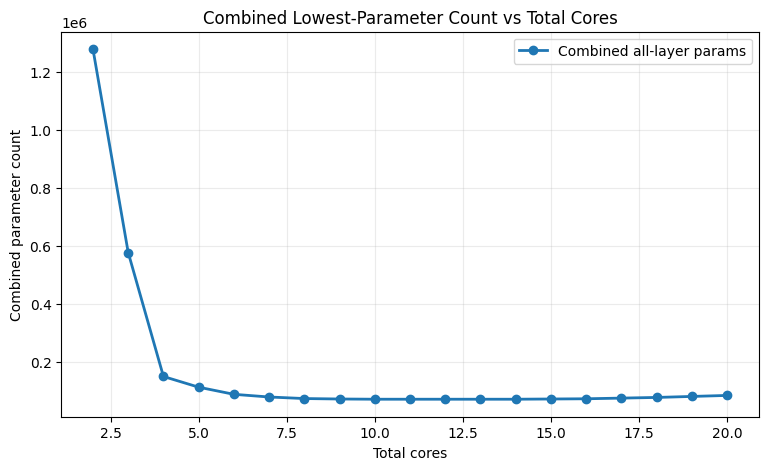

In [8]:
if plt is None:
    print('matplotlib is not available in this environment; skipping plot.')
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        combine_df['total_cores'],
        combine_df['combined_all_layers_params'],
        marker='o',
        linewidth=2,
        color='tab:blue',
        label='Combined all-layer params',
    )
    ax.set_title('Combined Lowest-Parameter Count vs Total Cores')
    ax.set_xlabel('Total cores')
    ax.set_ylabel('Combined parameter count')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()
